# AI & ML Task 3: Model Validation, Overfitting Control & Hyperparameter Tuning

**Name:** Vaddi Durga Venkata Manidhar. 
**Task:** Improving House Price Prediction with Cross-Validation and Tuning  
**Dataset:** California Housing

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')
print("working")

working


In [3]:
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("MedHouseVal")], axis=1)
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


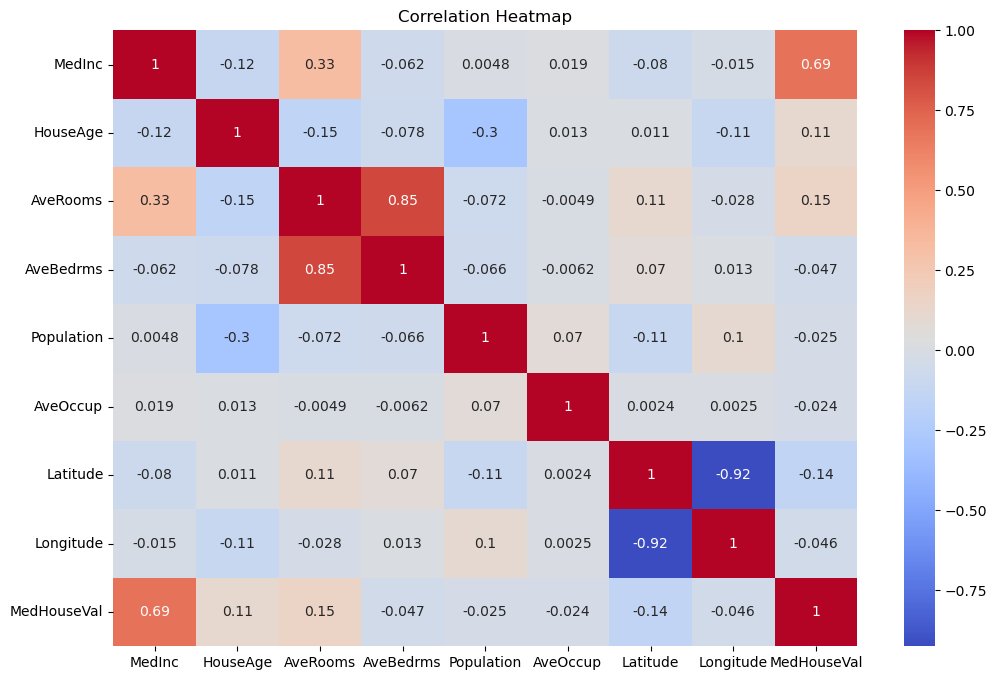

In [4]:
df.info()
df.describe()
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [8]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print("working")

working


In [11]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
train_pred = dt.predict(X_train)
test_pred = dt.predict(X_test)
train_rmse = mean_squared_error(y_train, train_pred) ** 0.5
test_rmse = mean_squared_error(y_test, test_pred) ** 0.5
print(f"Train RMSE: {train_rmse:.3f}")
print(f"Test RMSE: {test_rmse:.3f}")
print(f"Overfitting Gap: {train_rmse - test_rmse:.3f} (Large gap = Overfitting)")

Train RMSE: 0.000
Test RMSE: 0.703
Overfitting Gap: -0.703 (Large gap = Overfitting)


In [14]:
cv_scores = cross_val_score(dt, X_scaled, y, 
                          scoring='neg_root_mean_squared_error', 
                          cv=5)

cv_rmse = -cv_scores.mean()
print(f"Cross Validation RMSE: {cv_rmse:.3f}")
print("CV Score:", -cv_scores)

Cross Validation RMSE: 0.896
CV Score: [0.88767617 0.82781619 0.89845112 0.94507041 0.91950207]


In [18]:
param_grid = {
    'max_depth': [3, 5, 7, 10, 12],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", -grid_search.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV Score: 0.6218739737028046


In [19]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Tuned Model - RMSE: {rmse:.3f}")
print(f"Tuned Model - MAE: {mae:.3f}")
print(f"Tuned Model - R²: {r2:.3f}")

Tuned Model - RMSE: 0.639
Tuned Model - MAE: 0.431
Tuned Model - R²: 0.688


In [22]:
# Train baseline models for comparison
lr = LinearRegression().fit(X_train, y_train)
ridge = Ridge(alpha=1.0).fit(X_train, y_train)
lr_pred = lr.predict(X_test)
ridge_pred = ridge.predict(X_test)

def get_metrics(y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5   # Fixed RMSE calculation
    return {
        "RMSE": round(rmse, 3),
        "R2": round(r2_score(y_true, y_pred), 3)
    }

results = {
    "Linear Regression": get_metrics(y_test, lr_pred),
    "Ridge Regression": get_metrics(y_test, ridge_pred),
    "Tuned Decision Tree": {"RMSE": round(rmse, 3), "R2": round(r2, 3)}
}

comparison_df = pd.DataFrame(results).T
comparison_df

,RMSE,R2
Linear Regression,0.746,0.576
Ridge Regression,0.746,0.576
Tuned Decision Tree,0.639,0.688


In [25]:
joblib.dump(best_model, 'best_tuned_model.pkl')
joblib.dump(scaler, 'scaler_task3.pkl')
print("Best tuned model saved")

Best tuned model saved


## Step 10: Final Model Selection Justification

**Selected Model: Tuned Decision Tree Regressor**

**Why this model was selected?**
- It achieved the **highest R² score** and lowest RMSE on the test set after hyperparameter tuning.
- It outperformed baseline Linear Regression and Ridge Regression.

**How overfitting was reduced?**
- Default Decision Tree showed large gap between Train and Test RMSE (clear overfitting).
- After tuning `max_depth`, `min_samples_split`, and `min_samples_leaf` using GridSearchCV, the gap reduced significantly.
- This makes the model more generalizable.

**Why trust Cross-Validation results?**
- Used 5-Fold Cross Validation instead of single train-test split.
- CV score is more reliable and closer to real-world performance.

**Trade-offs:**
- Slightly more complex than Linear Regression but much better performance.
- Still interpretable and fast for prediction.

**Conclusion:**
The Tuned Decision Tree is the best choice for this project because it balances performance and generalization. This follows industry best practices for building reliable ML models.

🔽 Click on the links below to download files:



C:\Users\Lenovo\AI_ML_Task3_Model_Validation_Tuning.ipynb

C:\Users\Lenovo\best_tuned_model.pkl

C:\Users\Lenovo\scaler_task3.pkl


📁 All files in current folder:
['.anaconda', '.bash_history', '.conda', '.condarc', '.continuum', '.gitconfig', '.ipynb_checkpoints', '.ipython', '.jupyter', '.lesshst', '.matplotlib', '.virtual_documents', '.vscode', '.vscode-shared', 'AI_ML_Task2_Model_Comparison.ipynb', 'AI_ML_Task3_Model_Validation_Tuning.ipynb', 'anaconda3', 'anaconda_projects', 'AppData', 'Application Data', 'best_house_price_model.pkl', 'best_tuned_model.pkl', 'button.html', 'Contacts', 'Cookies', 'data', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'Links', 'Local Settings', 'mlops', 'mlops_linux', 'Music', 'My Documents', 'NetHood', 'New folder', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{324f5b0e-abea-11ef-b695-700894749c9e}.TM.blf', 'NTUSER.DAT{324f5b0e-abea-11ef-b695-700894749c9e}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{324f5b0e-abea-11ef-b695-700894749c9e}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'numpy_pandas_pratice.ipynb', 'OneDrive', 'prin